#### R2P Program Unit 2: Lesson 1
# Solve utility-scale quantum optimization problems

*Estimated QPU usage: 15 minutes (tested on IBM Fez)*

This tutorial demonstrates how to implement the **Quantum Approximate Optimization Algorithm (QAOA)** – a hybrid (quantum-classical) iterative method – within the context of Qiskit patterns. You will first solve the **Maximum-Cut** (or **Max-Cut**) problem for a small graph and then learn how to execute it at utility scale.

The Max-Cut problem is an optimization problem that is hard to solve (more specifically, it is an *NP-hard* problem) with a number of different applications in clustering, network science, and statistical physics. This tutorial considers a graph of nodes connected by vertices, and aims to partition it into separate graphs such that they are both as large as possible. Put another way, the goal of this problem is to partition the nodes of a graph into two sets such that the number of edges traversed by this cut is maximized.

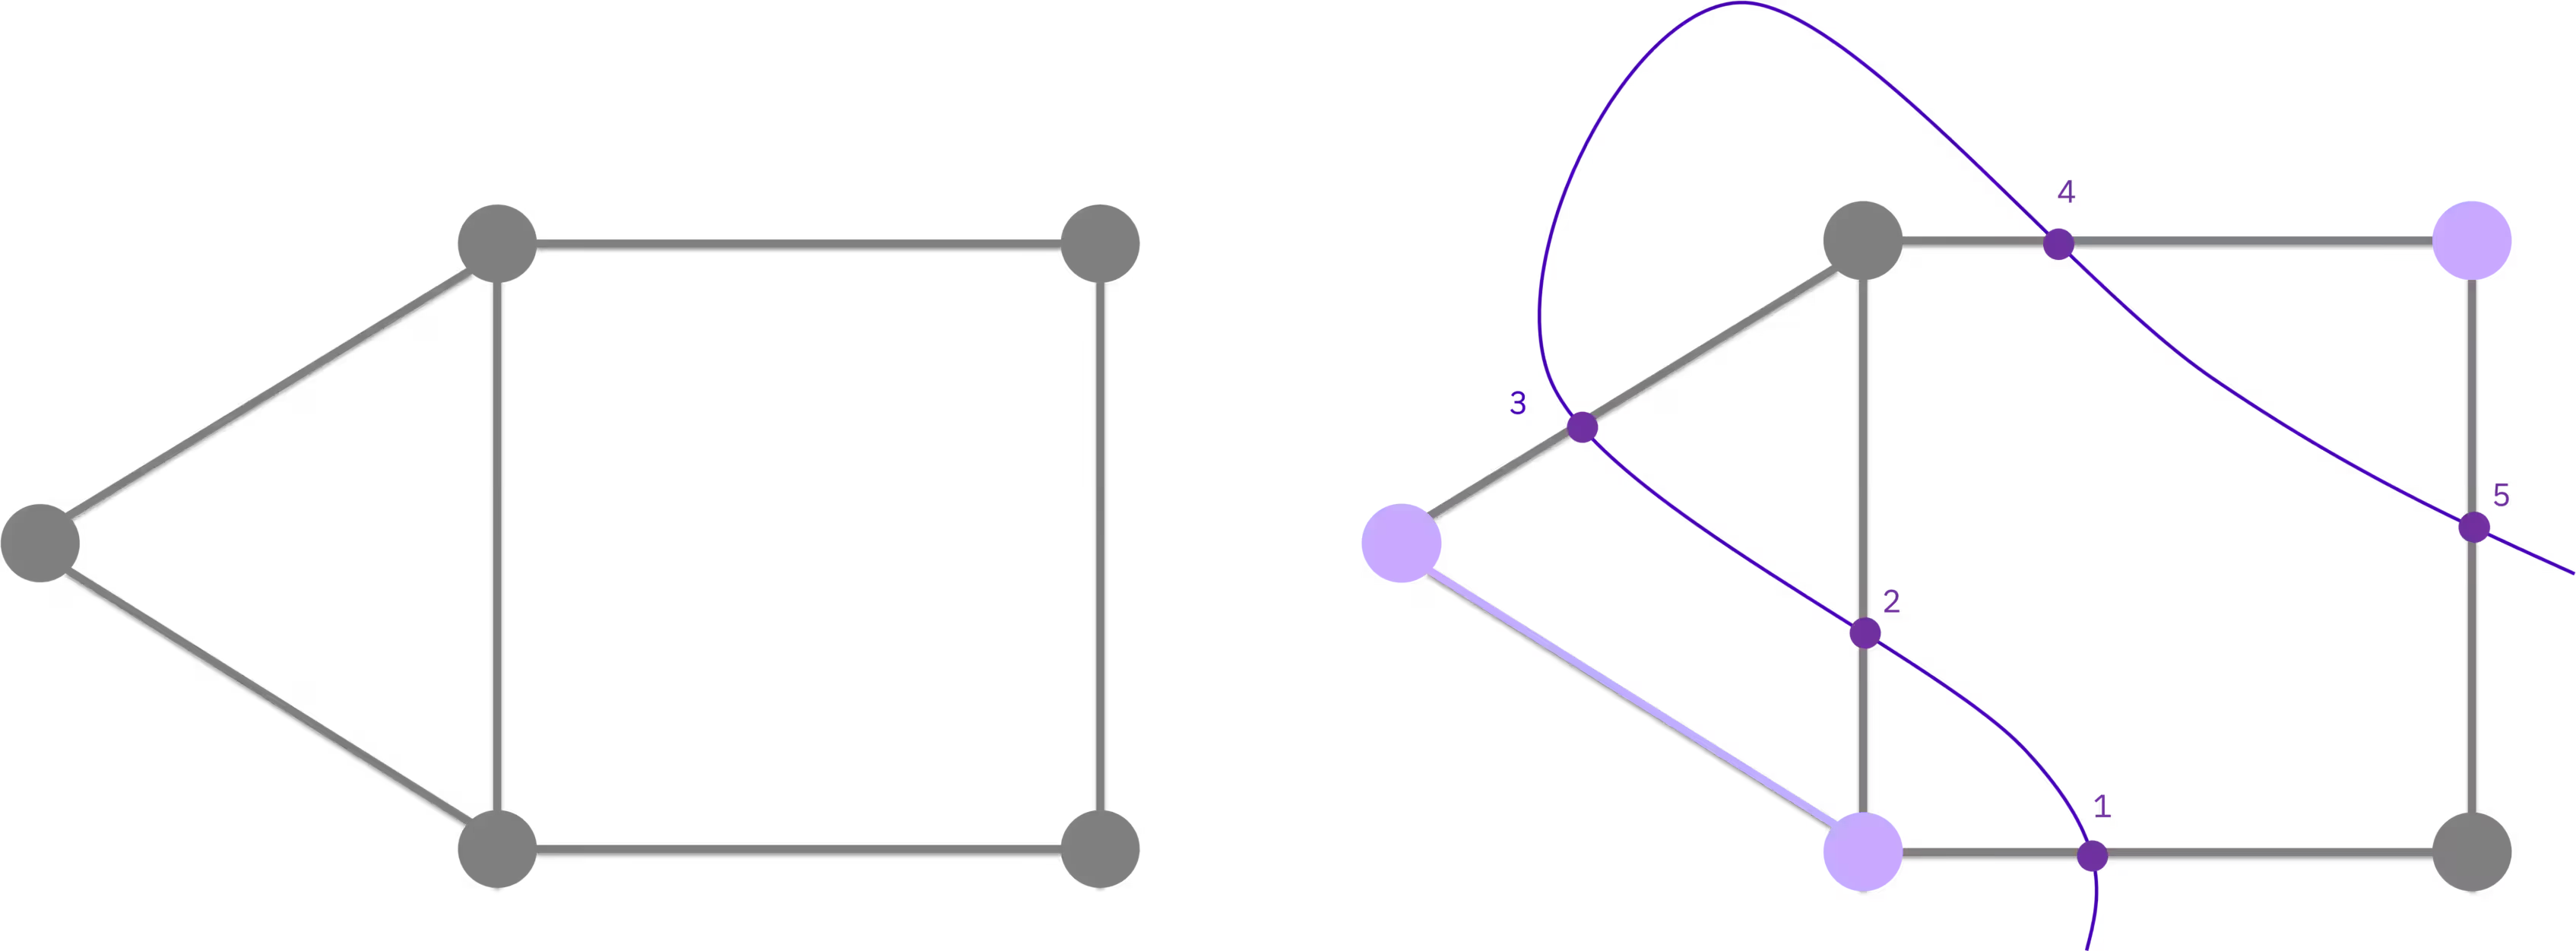

## Requirements

Before starting this tutorial, be sure you have the following installed:

* Qiskit SDK v1.0 or later, with visualization support ( `pip install 'qiskit[visualization]'` )
* Qiskit Runtime 0.22 or later (`pip install qiskit-ibm-runtime`)
* Rustworkx graph library (`pip install rustworkx`)


## Part 1: Small-scale QAOA

The first part of this tutorial uses a small-scale Max-Cut problem to illustrate the steps to solve an optimization problem using a quantum computer.

To give some context before mapping this problem to a quantum algorithm, you can better understand how the Max-Cut problem becomes a classical combinatorial optimization problem by first considering the minimization of a function $f(x)$

$$
\min_{x\in \{0, 1\}^n}f(x),
$$

where the input $x = [x_1, x_2, ... , x_n]$ is a vector whose components correspond to each node of an $n$-node graph. We constrain each of the vector components $x_i$ to either be $0$ or $1$ (which represents their binary classification after the nodes are separated by the cut). The small-scale example above uses a graph with $n=5$ nodes which corresponds to a vector $x = [x_1, x_2, x_3, x_4, x_5]$. 

You could write a function of a pair of nodes $i,j$ which indicates whether the corresponding edge $(i,j)$ is in the cut. Any edge in the cut connects two nodes of different binary values, e.g. if the edge $(i,j)$ is in the cut, it means either $x_i=0$ and $x_j=1$ or $x_i=1$ and $x_j=0$. Therefore, the function $x_i + x_j - 2 x_i x_j$ only equals 1 if one of either $x_i$ or $x_j$ are 1 and the other is 0 (this means that the edge connecting $x_i$ and $x_j$ is in the cut) and zero otherwise (meaning the edge is not in the cut). 

The problem of maximizing the edges in the cut can then be formulated as a maximisation over this function:

$$
\max_{x\in \{0, 1\}^n} \sum_{(i,j)} x_i + x_j - 2 x_i x_j,
$$

which can be rewritten as a minimization of the form

$$
\min_{x\in \{0, 1\}^n} \sum_{(i,j)}  2 x_i x_j - x_i - x_j.
$$

The minimum of $f(x)=\sum_{(i,j)}  2 x_i x_j - x_i - x_j$ in this case is when the number of edges traversed by the cut is maximal. As you can see, there is nothing relating to quantum computing yet. You need to reformulate this problem into something that a quantum computer can understand.


Initialize your problem by creating a graph with $n=5$ nodes.


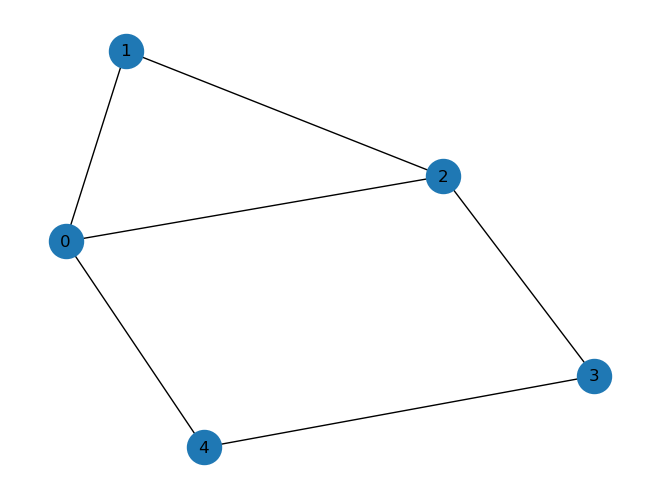

In [2]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np

n = 5

graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1))
edge_list = [(0, 1, 1.0),
             (0, 2, 1.0), 
             (0, 4, 1.0), 
             (1, 2, 1.0), 
             (2, 3, 1.0), 
             (3, 4, 1.0)]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

### Step 1. Map classical inputs to a quantum problem

The first step of the pattern is to map the classical problem (graph) into quantum **circuits** and **operators**. To do this, there are three main steps to take:

1. Utilize a series of mathematical reformulations, to represent this problem using the Quadratic Unconstrained Binary Optimization (QUBO) problems notation.
2. Rewrite the optimization problem as a Hamiltonian for which the ground state corresponds to the solution which minimizes the cost function.
3. Create a quantum circuit which will prepare the ground state of this Hamiltonian via a process similar to quantum annealing.

**Note:** In the QAOA methodology, you ultimately want to have an operator (**Hamiltonian**) that represents the **cost function** of our hybrid algorithm, as well as a parametrized circuit (**Ansatz**) that represents quantum states with candidate solutions to the problem. You can sample from these candidate states and then evaluate them using the cost function.

#### Graph → optimization problem

The first step of the mapping is a notation change, The following expresses the problem in QUBO notation:

$$
\min_{x\in \{0, 1\}^n}x^T Q x,
$$

where $Q$ is a $n\times n$ matrix of real numbers, $n$ corresponds to the number of nodes in your graph, $x$ is the vector of binary variables introduced above, and $x^T$ indicates the transpose of the vector $x$.



### Optimization problem → Hamiltonian

You can then reformulate the QUBO problem as a **Hamiltonian** (here, a matrix that represents the energy of a system):

$$
H_C=\sum_{ij}Q_{ij}Z_iZ_j + \sum_i b_iZ_i.
$$

> **Reformulation steps from QUBO problem to the Hamiltonian**

> To demonstrate how the QUBO problem can be rewritten in this way, first replace the binary variables $x_i$ to a new set of variables $z_i\in\{-1, 1\}$ via
>
> $$
> x_i = \frac{1-z_i}{2}.
> $$
>
> Here you can see that if $x_i$ is $0$, then $z_i$ must be $1$. When the $x_i$'s are substituted for the $z_i$'s in the optimization problem ($x^TQx$), an equivalent formulation can be obtained.
>
> $$
> x^TQx=\sum_{ij}Q_{ij}x_ix_j \\ =\frac{1}{4}\sum_{ij}Q_{ij}(1-z_i)(1-z_j) \\=\frac{1}{4}\sum_{ij}Q_{ij}z_iz_j-\frac{1}{4}\sum_{ij}(Q_{ij}+Q_{ji})z_i + \frac{n^2}{4}.
> $$
>
> Now if we define $b_i=-\sum_{j}(Q_{ij}+Q_{ji})$, remove the prefactor, and the constant $n^2$ term, we arrive at the two equivalent formulations of the same optimization problem.
>
> $$
> \min_{x\in\{0,1\}^n} x^TQx\Longleftrightarrow \min_{z\in\{-1,1\}^n}z^TQz + b^Tz
> $$
>
> Here, $b$ depends on $Q$. Note that to obtain $z^TQz + b^Tz$ we dropped the factor of 1/4 and a constant offset of $n^2$ which do not play a role in the optimization.
>
> Now, to obtain a quantum formulation of the problem, promote the $z_i$ variables to a Pauli $Z$ matrix, such as a $2\times 2$ matrix of the form
>
> $$
> Z_i = \begin{pmatrix}1 & 0 \\ 0 & -1\end{pmatrix}.
> $$
>
> When you substitute these matrices in the optimization problem above, you obtain the following Hamiltonian
>
> $$
> H_C=\sum_{ij}Q_{ij}Z_iZ_j + \sum_i b_iZ_i.
> $$
>
> *Also recall that the $Z$ matrices are embedded in the quantum computer's computational space, i.e., a Hilbert space of size $2^n\times 2^n$. Therefore, you should understand terms such as $Z_iZ_j$ as the tensor product $Z_i\otimes Z_j$ embedded in the $2^n\times 2^n$ Hilbert space. For example, in a problem with five decision variables the term $Z_1Z_3$ is understood to mean $I\otimes Z_3\otimes I\otimes Z_1\otimes I$ where $I$ is the $2\times 2$ identity matrix.*

This Hamiltonian is called the <b>cost function Hamiltonian</b>. It has the property that its ground state corresponds to the solution that <b>minimizes the cost function $f(x)$</b>.
Therefore, to solve your optimization problem you now need to prepare the ground state of $H_C$ (or a state with a high overlap with it) on the quantum computer. Then, sampling from this state will, with a high probability, yield the solution to $min~f(x)$.


Now let us consider the Hamiltonian $H_C$ for the **Max-Cut** problem. Let each node of the graph be associated with a qubit in state $|0\rangle$ or $|1\rangle$, where the value denotes the set the node is in. The goal of the problem is to maximize the number of edges $(v_1, v_2)$ for which $v_1 = |0\rangle$ and $v_2 = |1\rangle$, or vice-versa. If we associate the $Z$ operator with each qubit, where

$$
    Z|0\rangle = |0\rangle \qquad Z|1\rangle = -|1\rangle
$$

then an edge **$(v_1, v_2)$ belongs to the cut if the eigenvalue of $(Z_1|v_1\rangle) \cdot (Z_2|v_2\rangle) = -1$**; in other words, the qubits associated with $v_1$ and $v_2$ are different. Similarly, **$(v_1, v_2)$ does not belong to the cut if the eigenvalue of $(Z_1|v_1\rangle) \cdot (Z_2|v_2\rangle) = 1$**. Note that, we do not care about the exact qubit state associated with each node, rather we care only whether they are same or not across an edge. The Max-Cut problem requires us to find an assignment of the qubits on the vertices such that the eigenvalue of the following Hamiltonian is minimized

$$
    H_C = \sum_{(i,j) \in e} Q_{ij} \cdot Z_i Z_j.
$$

In other words, $b_i = 0$ for all $i$ in the Max-Cut problem. The value of $Q_{ij}$ denotes the weight of the edge. **In this hands-on we consider an unweighted graph, that is, $Q_{ij} = 1.0$ for all $i, j$.**



In [3]:
from sympy import Matrix
from qiskit.quantum_info import SparsePauliOp
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list."""
    pauli_list = []
    for edge in list(graph.edge_list()):
        paulis = ["I"] * len(graph)
        paulis[edge[0]], paulis[edge[1]] = "Z", "Z"

        weight = graph.get_edge_data(edge[0], edge[1])

        pauli_list.append(("".join(paulis)[::-1], weight))

    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
display(Matrix(cost_hamiltonian))
display('Diagonal',Matrix(np.diag(cost_hamiltonian.to_matrix())))

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'ZIIIZ', 'IIZZI', 'IZZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


Matrix([
[6.0, 0,   0, 0, 0,    0, 0,   0,   0,    0,    0,    0, 0,    0, 0,   0,   0, 0,    0, 0,    0,    0,    0,   0,   0, 0,    0, 0, 0,   0, 0,   0],
[  0, 0,   0, 0, 0,    0, 0,   0,   0,    0,    0,    0, 0,    0, 0,   0,   0, 0,    0, 0,    0,    0,    0,   0,   0, 0,    0, 0, 0,   0, 0,   0],
[  0, 0, 2.0, 0, 0,    0, 0,   0,   0,    0,    0,    0, 0,    0, 0,   0,   0, 0,    0, 0,    0,    0,    0,   0,   0, 0,    0, 0, 0,   0, 0,   0],
[  0, 0,   0, 0, 0,    0, 0,   0,   0,    0,    0,    0, 0,    0, 0,   0,   0, 0,    0, 0,    0,    0,    0,   0,   0, 0,    0, 0, 0,   0, 0,   0],
[  0, 0,   0, 0, 0,    0, 0,   0,   0,    0,    0,    0, 0,    0, 0,   0,   0, 0,    0, 0,    0,    0,    0,   0,   0, 0,    0, 0, 0,   0, 0,   0],
[  0, 0,   0, 0, 0, -2.0, 0,   0,   0,    0,    0,    0, 0,    0, 0,   0,   0, 0,    0, 0,    0,    0,    0,   0,   0, 0,    0, 0, 0,   0, 0,   0],
[  0, 0,   0, 0, 0,    0, 0,   0,   0,    0,    0,    0, 0,    0, 0,   0,   0, 0,    0, 0,    0,    0, 

'Diagonal'

Matrix([
[ 6.0],
[   0],
[ 2.0],
[   0],
[   0],
[-2.0],
[   0],
[ 2.0],
[ 2.0],
[-4.0],
[-2.0],
[-4.0],
[   0],
[-2.0],
[   0],
[ 2.0],
[ 2.0],
[   0],
[-2.0],
[   0],
[-4.0],
[-2.0],
[-4.0],
[ 2.0],
[ 2.0],
[   0],
[-2.0],
[   0],
[   0],
[ 2.0],
[   0],
[ 6.0]])

#### Hamiltonian → quantum circuit

The Hamiltonian $H_c$ contains the quantum definition of your problem. Now you can create a quantum circuit that will help *sample* good solutions from the quantum computer. The QAOA is inspired by quantum annealing and applies alternating layers of operators in the quantum circuit.

The general idea is to start in the ground state of a known system, $H^{\otimes n}|0\rangle$ above, and then steer the system into the ground state of the cost operator that you are interested in. This is done by applying the operators $\exp\{-i\gamma_k H_C\}$ and $\exp\{-i\beta_k H_m\}$ with angles $\gamma_1,...,\gamma_p$ and $\beta_1,...,\beta_p~$.

The quantum circuit that you generate is **parametrized** by $\gamma_i$ and $\beta_i$, so you can try out different values of $\gamma_i$ and $\beta_i$ and sample from the resulting state.

<div style="text-align: center;">
  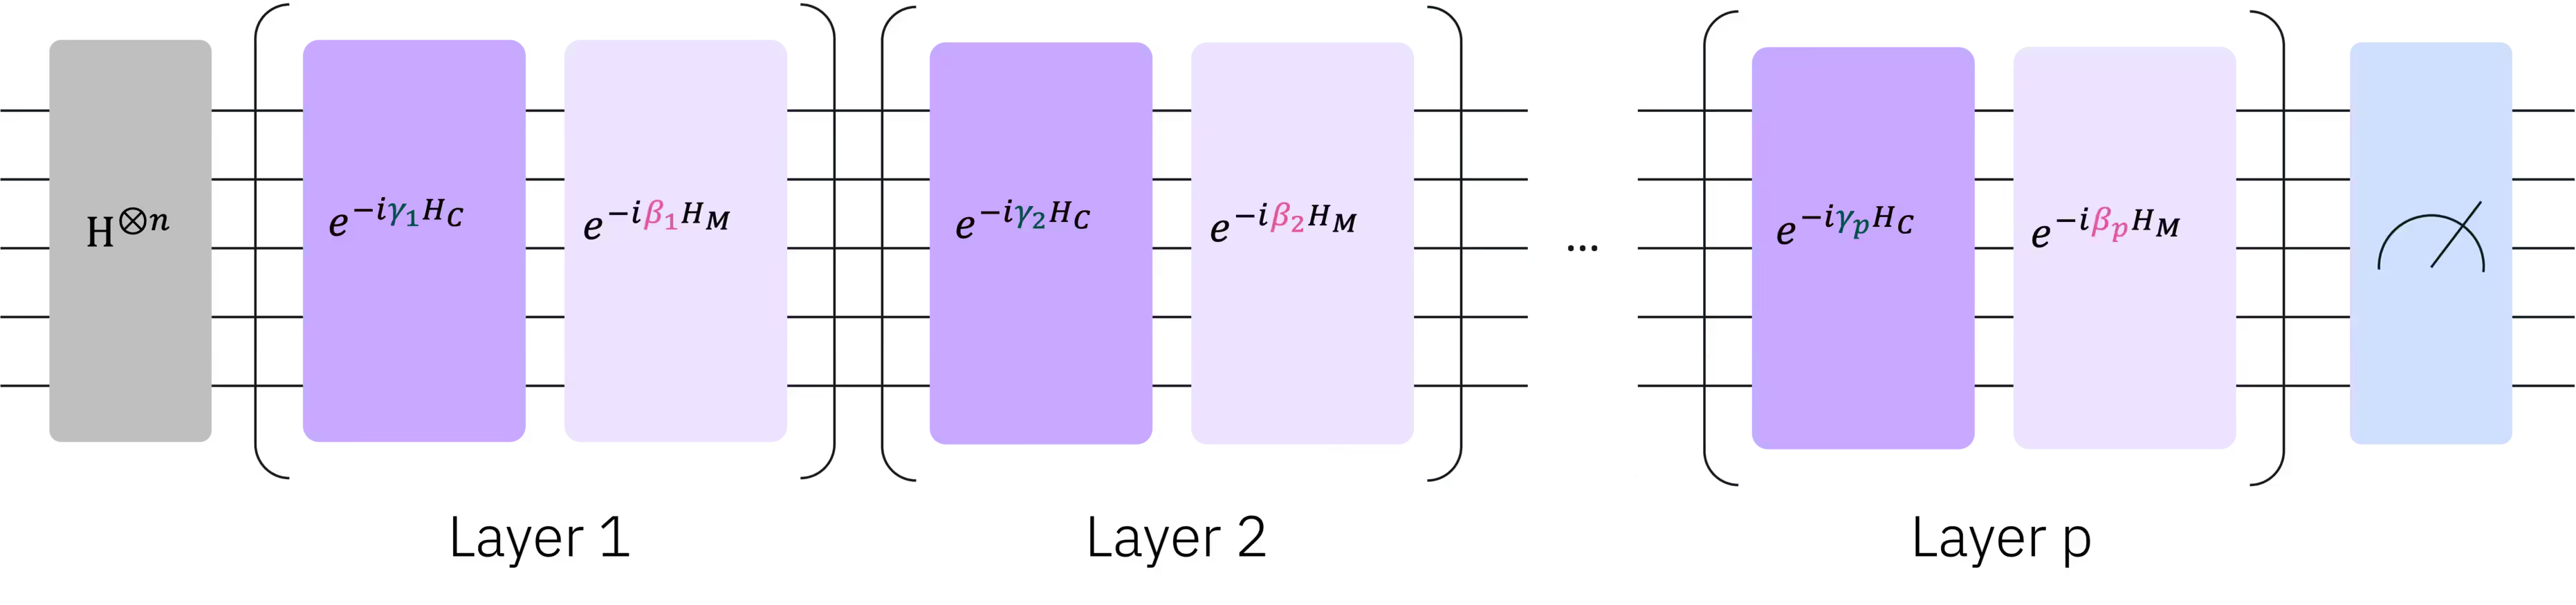
</div>

**Note:**
The operator $H^{\otimes n}$ prepares the uniform superposition that serves as the initial state. The unitary $e^{i\gamma_p H_C}$ then applies phase shifts determined by the problem Hamiltonian $H_C$, which leave the expectation value of $H_C$ unchanged.
Then, the unitary $e^{i\beta_p H_M}$ mixes amplitudes and explores the solution space to avoid the algorithm to stuck in a specific solution space.

#### Comparison with VQE

In this Lesson we also cover the Variational Quantum Eigensolver (VQE) algorithm. Although QAOA belongs to the same category to VQE and they have several points in common (to the point that they can be used interchangeably for most problems) it is convenient to highlight what are their main similarities and differences to give you a better understanding of these two popular variational algorithms.

| Feature                     | VQE (Variational Quantum Eigensolver)                        | QAOA (Quantum Approximate Optimization Algorithm)        |
|----------------------------|--------------------------------------------------------------|----------------------------------------------------------|
| **Main Goal**              | Estimate the ground state energy of a Hamiltonian            | Find approximate solutions to combinatorial optimization problems |
| **Use Cases**              | Quantum chemistry, physics simulations                       | Optimization (e.g. MaxCut, SAT, MIS)              |
| **Cost Function**          | Expectation value of the Hamiltonian                         | Cost function encoded in problem Hamiltonian             |
| **Ansatz Type**            | Physically inspired or hardware-efficient circuits           | Alternates cost and mixer Hamiltonians, scaled by tunable parameters   |
| **Classical Optimizer**    | Yes (used to update parameters of the Ansatz)                | Yes (used to optimize the weights of each Hamiltonian) |
| **Output**                 | Ground state and its energy                                  | Bitstring approximating the optimal solution             |
| **Scalability**            | Limited by expressibility of the Ansatz and optimization complexity                    | Limited by number of layers $p$ and optimization complexity |


Now that we have covered the theory of QAOA, we are ready to put this knowledge into practice!

In this noteboook, we will try an example with one QAOA layer that contains two parameters: $\gamma_1$ and $\beta_1$.


**Note:**
By default, the `QAOAAnsatz` uses the mixer Hamiltonian $H_M = X^{\otimes n}$.

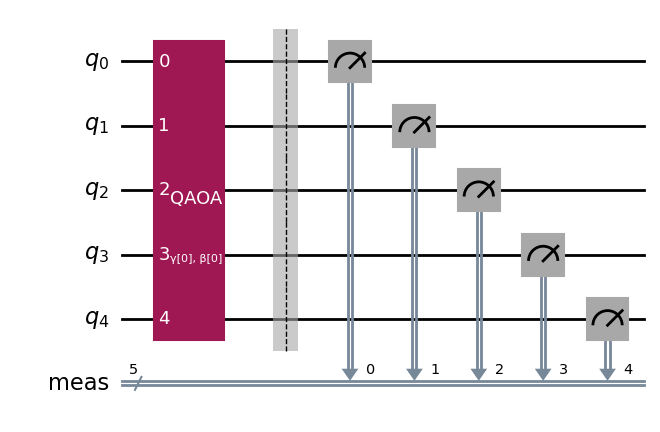

In [4]:
from qiskit.circuit.library import QAOAAnsatz

circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=1)
circuit.measure_all()

circuit.draw('mpl')

In [5]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(γ[0])])

### Step 2. Optimize circuits for quantum hardware execution


The circuit above contains a series of abstractions useful to think about quantum algorithms, but not possible to run on the hardware. To be able to run on a QPU, the circuit needs to undergo a series of operations that make up the **transpilation** or **circuit optimization** step of the pattern.

The Qiskit library offers a series of **transpilation passes** that cater to a wide range of circuit transformations. You need to make sure that your circuit is **optimized** for your purpose.

Transpilation may involves several steps, such as:

* **Initial mapping** of the qubits in the circuit (such as decision variables) to physical qubits on the device.
* **Unrolling** of the instructions in the quantum circuit to the hardware-native instructions that the backend understands.
* **Routing** of any qubits in the circuit that interact to physical qubits that are adjacent with one another.
* **Error suppression** by adding single-qubit gates to suppress noise with dynamical decoupling.

More information about transpilation is available in our [documentation](https://docs.quantum.ibm.com/transpile).

The following code transforms and optimizes the abstract circuit into a format that is ready for execution on one of devices accessible through the cloud using the **Qiskit IBM Runtime service**.


### Simulator-backend call

We are using aer_simulator_from(ibm_fez)


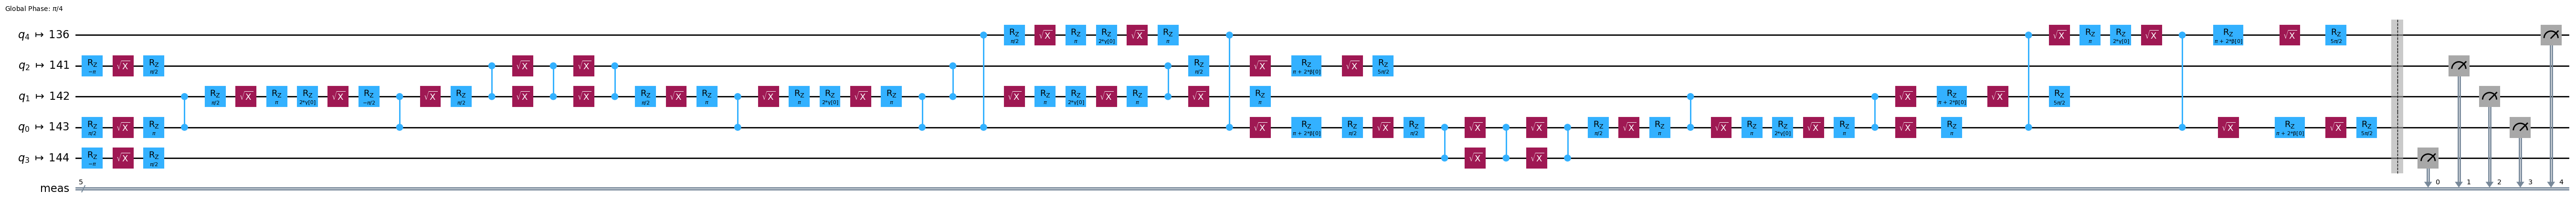

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService(channel='ibm_quantum_platform')
real_backend = service.least_busy(
    simulator=False, operational=True, min_num_qubits=156
)

from qiskit_aer import AerSimulator
backend=AerSimulator.from_backend(real_backend)
print(f"We are using {backend.name}")
# Create pass manager for transpilation
pm = generate_preset_pass_manager(optimization_level=3,
                                    backend=backend,
                                    seed_transpiler=42)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw('mpl', fold=False, idle_wires=False)

### If you want to run it on a real hardware execute the cell below

We are using ibm_marrakesh


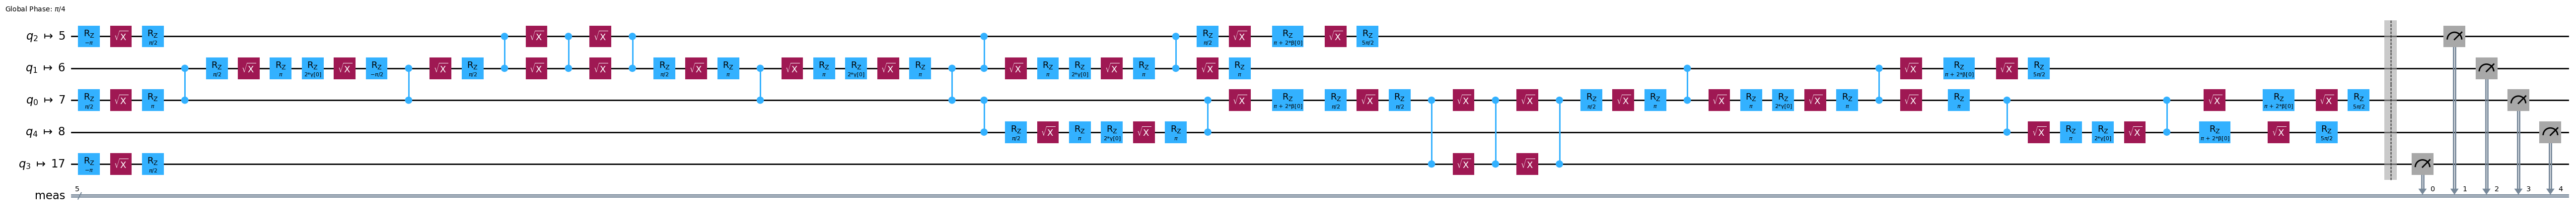

In [10]:
backend = real_backend
# Print the backend
print(f"We are using {backend.name}")
# Create pass manager for transpilation
pm = generate_preset_pass_manager(optimization_level=3,
                                    backend=backend,
                                    seed_transpiler=42)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw('mpl', fold=False, idle_wires=False)

### Step 3. Execute using Qiskit primitives


In the QAOA workflow, the optimal QAOA parameters are found in an iterative optimization loop, which runs a series of circuit evaluations and uses a classical optimizer to find the optimal $\beta_k$ and $\gamma_k$ parameters. This execution loop is executed via the following steps:

1. Define the initial parameters
2. Instantiate a new `Session` containing the optimization loop and the primitive used to sample the circuit
3. Once an optimal set of parameters is found, execute the circuit a final time to obtain a final distribution which will be used in the post-process step.


#### Define circuit with initial parameters

We start with arbitrary chosen parameters.


In [7]:
init_params = [0]*candidate_circuit.num_parameters

#### Define backend and execution primitive

Use the **Qiskit Runtime primitives** to interact with IBM® backends. The two primitives are Sampler and Estimator, and the choice of primitive depends on what type of measurement you want to run on the quantum computer. For the minimization of $H_c$, use the Estimator since the measurement of the cost function is simply the expectation value of $\langle H_c \rangle$.


#### Run

The primitives offer a variety of [execution modes](https://docs.quantum.ibm.com/run/execution-modes) to schedule workloads on quantum devices, and a QAOA workflow runs iteratively in a session.

<div style="text-align: center;">
  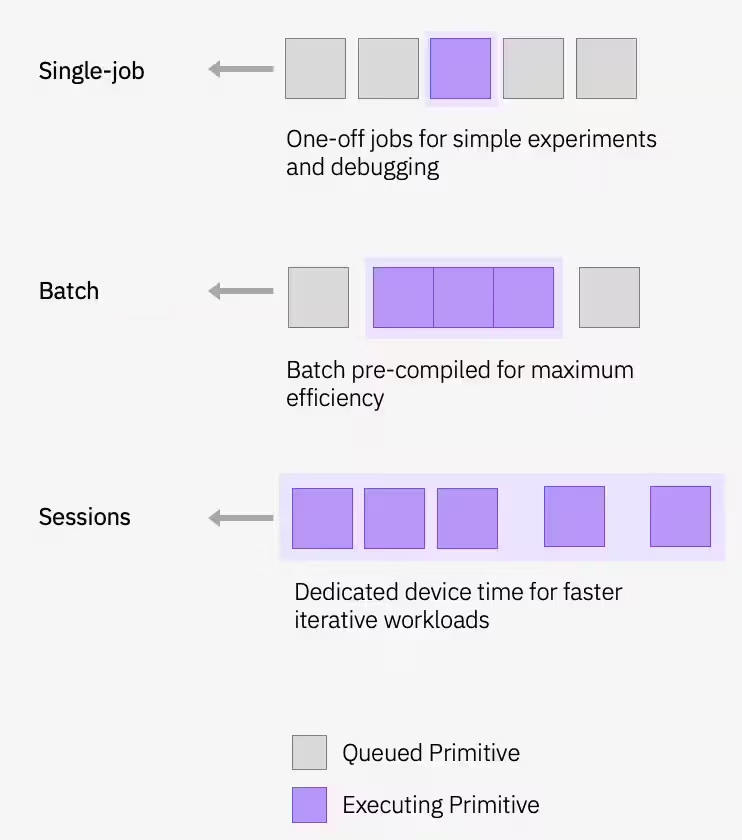
</div>

You can plug the sampler-based cost function into the SciPy minimizing routine to find the optimal parameters.

In [8]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):

    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)


    return cost

In [9]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from scipy.optimize import minimize

objective_func_vals = [] # Global variable
with Session(backend=backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        options={
            "maxiter": 30, 
            "tol": 1e-2,
        },
    )
    print(result)

/Users/jma/miniconda3/envs/3139/lib/python3.13/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:269: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -2.0999000999001
       x: [ 1.959e+00 -3.123e-01]
    nfev: 19
   maxcv: 0.0


The optimizer was able to reduce the cost and find better parameters for the circuit.


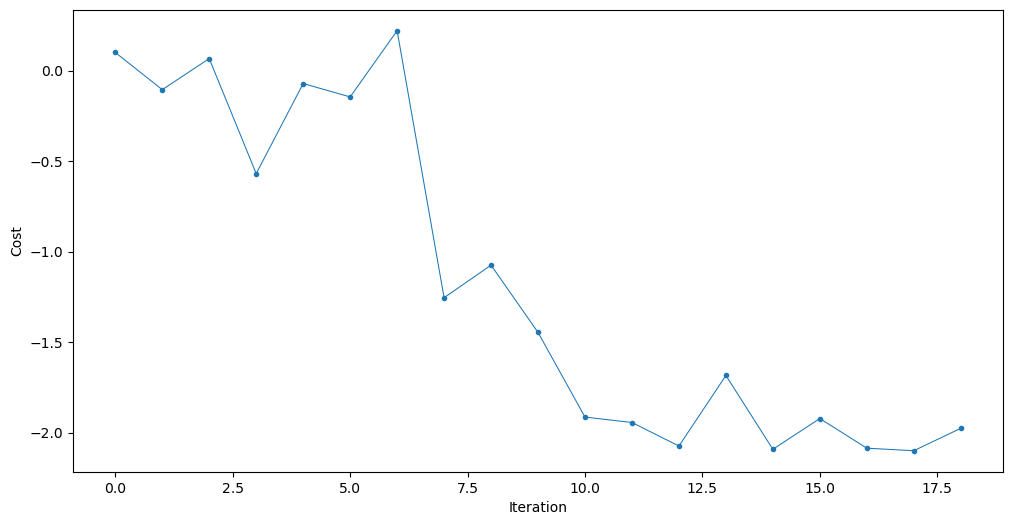

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals,lw=0.75,marker='.')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

Once you have found the optimal parameters for the circuit, you can assign these parameters and sample the final distribution obtained with the optimized parameters. Here is where the *Sampler* primitive should be used since it is the probability distribution of bitstring measurements which correspond to the optimal cut of the graph.

**Note:** This means preparing a quantum state $\psi$ in the computer and then measuring it. A measurement will collapse the state into a single computational basis state - for example, `010101110000...` - which corresponds to a candidate solution $x$ to our initial optimization problem ($\max f(x)$ or $\min f(x)$ depending on the task).


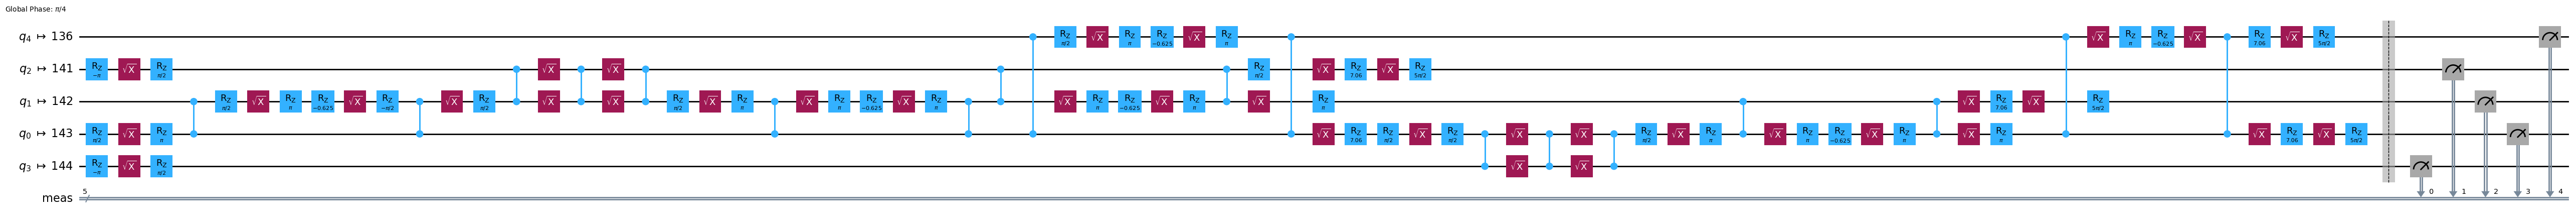

In [11]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw('mpl', fold=False, idle_wires=False)

In [12]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub= (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}
print(final_distribution_int)

{30: 0.0121, 22: 0.0954, 17: 0.0285, 2: 0.0044, 20: 0.0977, 9: 0.0999, 18: 0.044, 1: 0.0124, 15: 0.0062, 29: 0.0051, 7: 0.0049, 13: 0.047, 16: 0.0068, 11: 0.1047, 26: 0.0666, 21: 0.0495, 3: 0.016, 27: 0.0111, 19: 0.03, 5: 0.0658, 24: 0.006, 14: 0.029, 10: 0.0465, 12: 0.0282, 23: 0.0068, 0: 0.0059, 4: 0.0116, 28: 0.0163, 8: 0.0065, 6: 0.0143, 31: 0.0058, 25: 0.015}


### Step 4. Post-process, return result in classical format

The post-processing step interprets the sampling output to return a solution for your original problem. In this case, you are interested in the bitstring with the highest probability as this determines the optimal cut. The symmetries in the problem allow for four possible solutions, and the sampling process will return one of them with a slightly higher probability, but you can see in the plotted distribution below that four of the bitstrings are distictively more likely than the rest.


In [13]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [1, 1, 0, 1, 0]


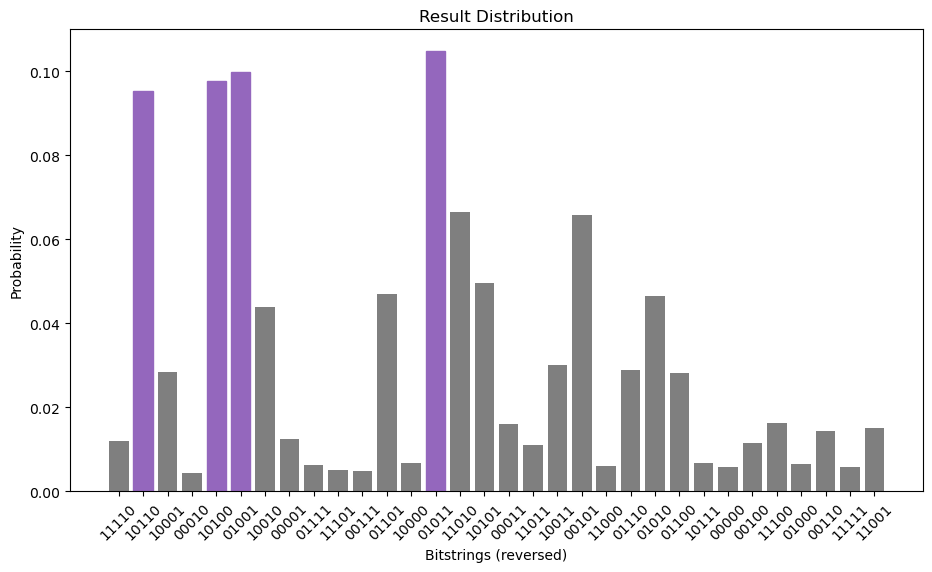

In [14]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(np.array(list(final_bits.values()), dtype=float))
top_4_values = sorted(values, reverse=True)[:4]

fig, ax = plt.subplots(figsize=(11, 6))
plt.xticks(rotation=45)
ax.set_title("Result Distribution")
ax.set_xlabel("Bitstrings (reversed)")
ax.set_ylabel("Probability")

bars = ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")

for value in top_4_values:
    idxs = np.where(values == value)[0]   # array of indices
    for idx in idxs:                      # color all ties
        bars[int(idx)].set_color("tab:purple")

plt.show()

#### Visualize best cut

From the optimal bit string, you can then visualize this cut on the original graph.


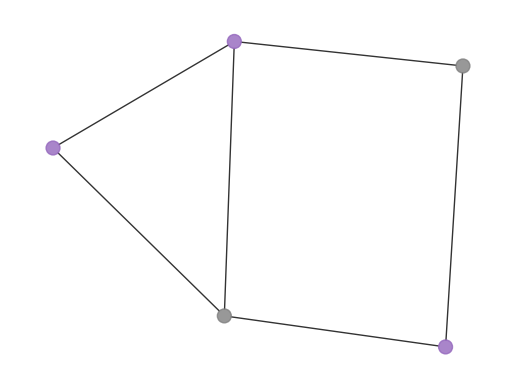

In [15]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(G, node_color=colors, node_size=100, alpha=0.8, pos=pos)


plot_result(graph, most_likely_bitstring)

**Your result should be similar to the image at the beginning**

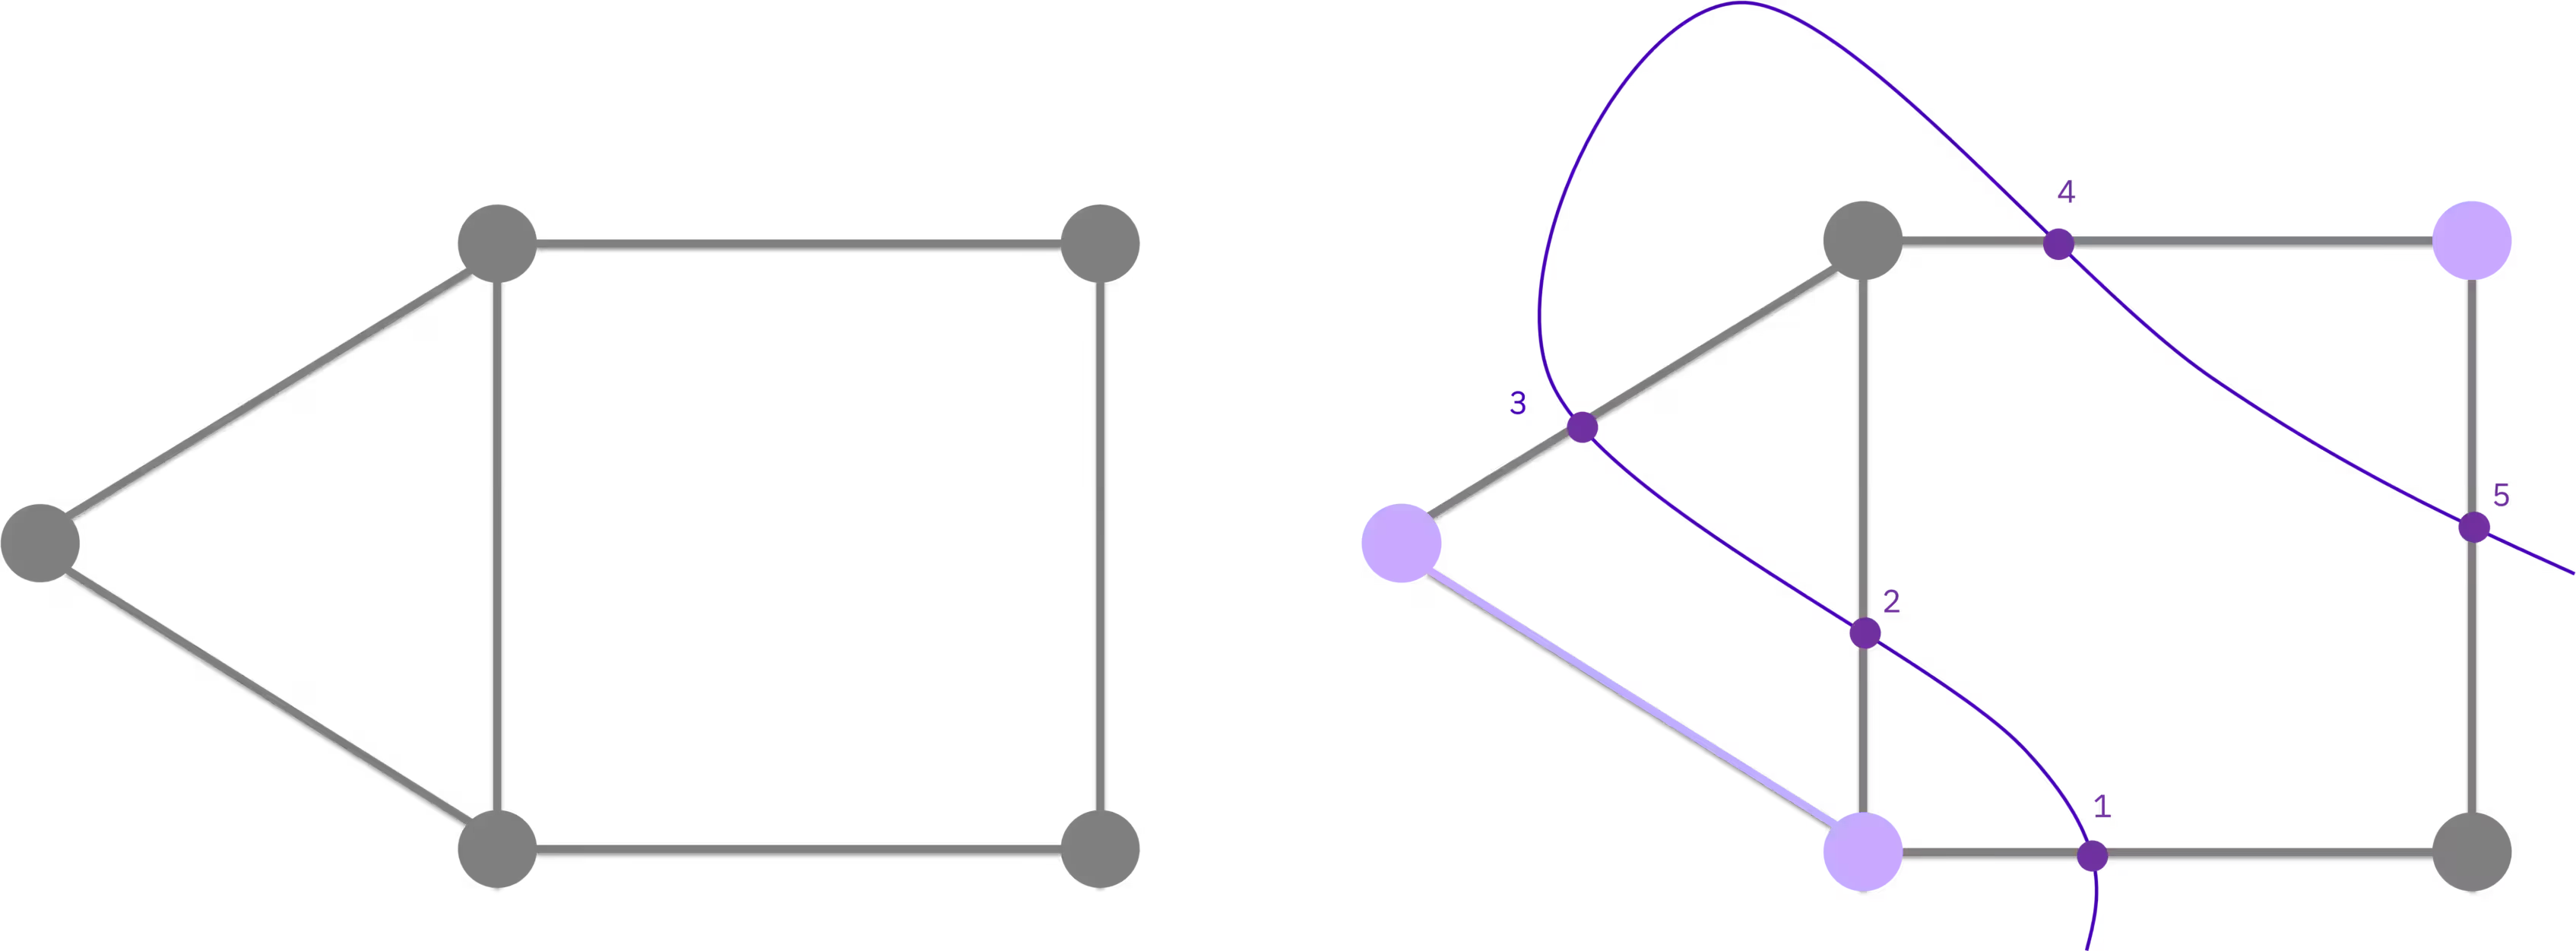

And calculate the value of the cut


In [16]:
from typing import Sequence
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(list(graph.nodes())), "The length of x must coincide with the number of nodes in the graph."
    return sum(x[u] * (1 - x[v]) + x[v] * (1 - x[u]) for u, v in list(graph.edge_list()))


cut_value= evaluate_sample(most_likely_bitstring, graph)
print('The value of the cut is:', cut_value)

The value of the cut is: 5


## Part 2: scale it up!

You have access to many devices with over 100 qubits on IBM Quantum Platform. Select one on which to solve Max-Cut on a 100-node weighted graph. This is a "utility-scale" problem. The steps to build the workflow are followed the same as above, but with a much larger graph.


In [17]:
# Choose a real backend
service = QiskitRuntimeService(channel='ibm_quantum_platform',)
backend = service.least_busy(min_num_qubits=156)
# print backend details
print(
    f"Name: {backend.name}\n"
    f"Version: {backend.backend_version}\n"
    f"No. of qubits: {backend.num_qubits}\n"
    f"Processor type: {backend.processor_type}\n"
)


Name: ibm_fez
Version: 1.3.37
No. of qubits: 156
Processor type: {'family': 'Heron', 'revision': '2'}



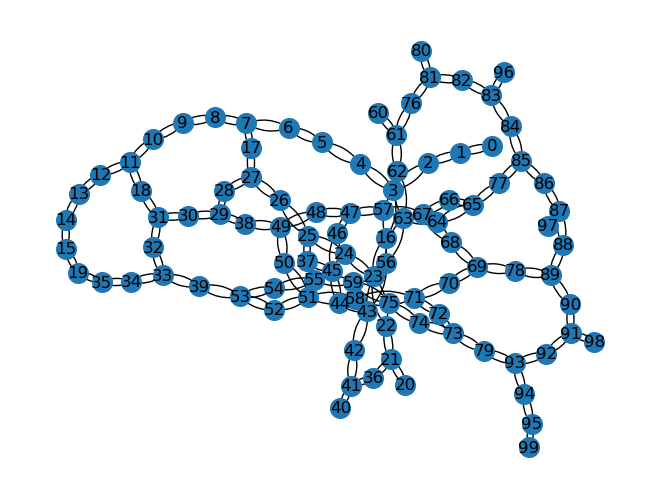

In [19]:
n = 100  # Number of nodes in graph
graph_100 = rx.PyGraph()
graph_100.add_nodes_from(np.arange(0, n, 1))
elist = []
for edge in backend.coupling_map:
    if edge[0] < n and edge[1] < n:
        elist.append((edge[0], edge[1], 1.0))
graph_100.add_edges_from(elist)
draw_graph(graph_100, node_size=200, with_labels=True, width=1)

### Step 1. Map classical inputs to a quantum problem


#### Graph → Hamiltonian

First, convert the graph you want to solve directly into a Hamiltonian that is suited for QAOA.


In [20]:
max_cut_paulis_100 = build_max_cut_paulis(graph_100)

cost_hamiltonian_100 = SparsePauliOp.from_list(max_cut_paulis_100)
print("Cost Function Hamiltonian:", cost_hamiltonian_100)

Cost Function Hamiltonian: SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIII', 'IIIIIIIIIIIIIIIIIIIII

#### Hamiltonian → quantum circuit


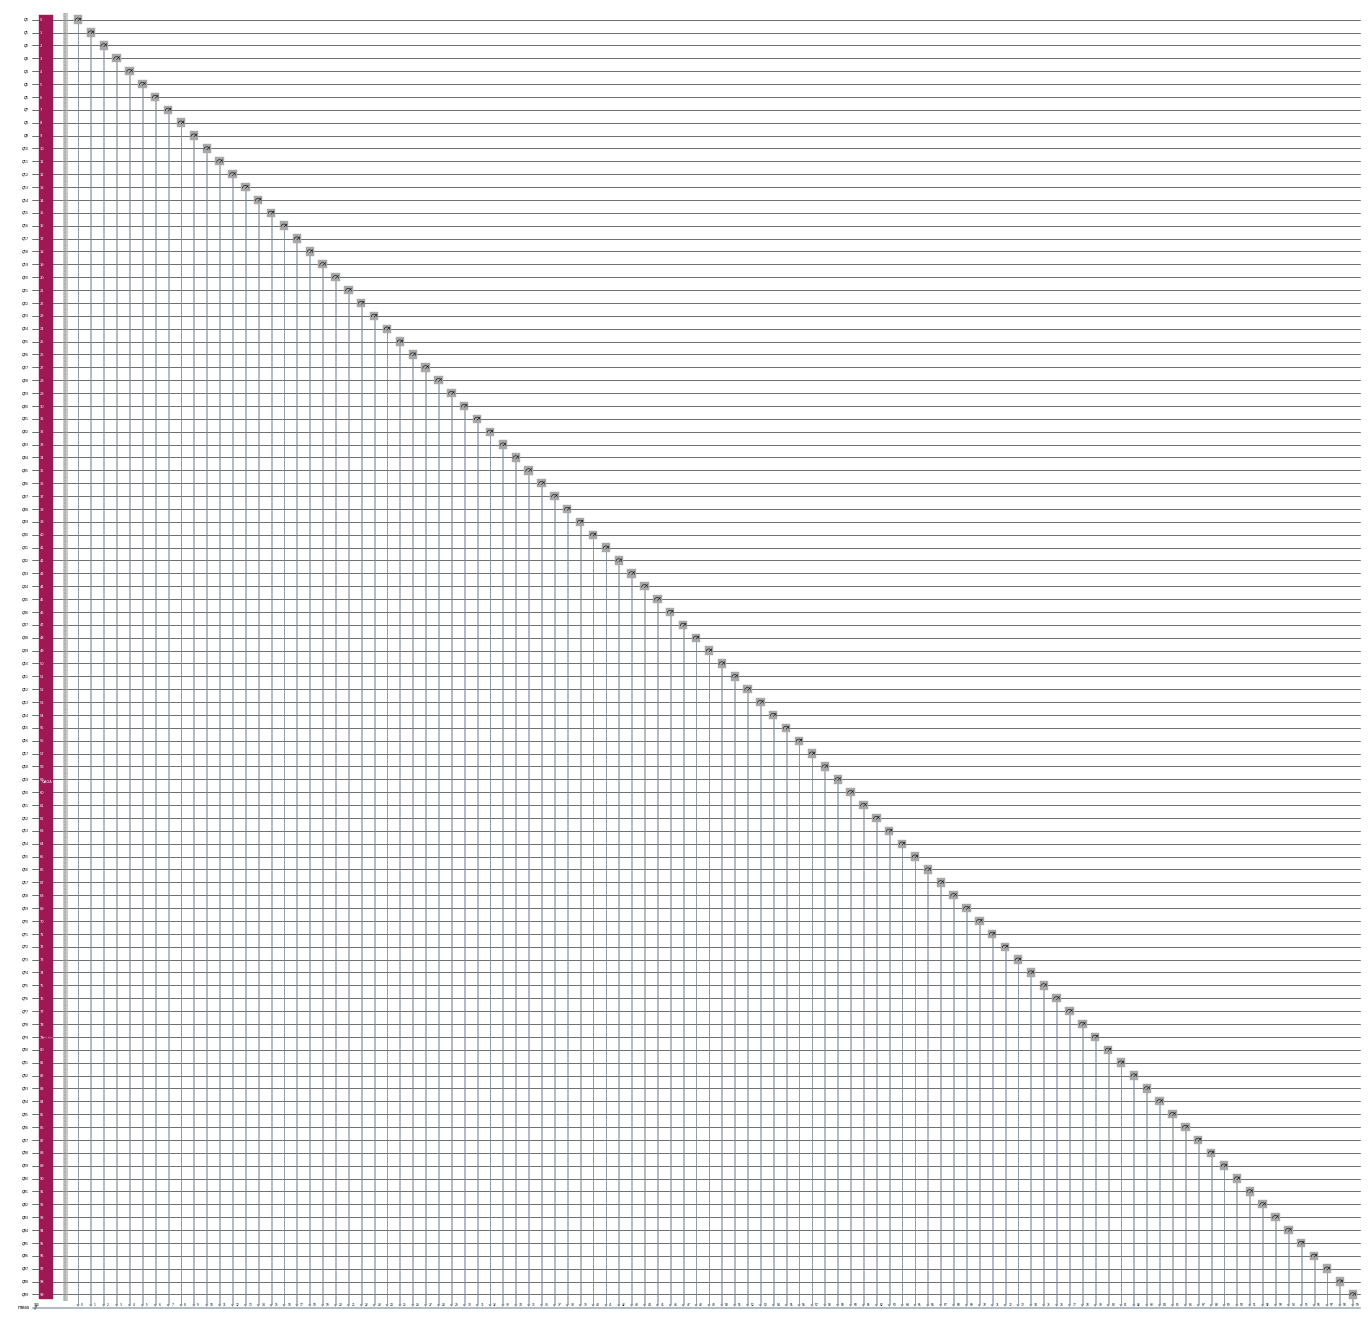

In [21]:
from qiskit.circuit.library import QAOAAnsatz

layers=1
circuit_100 = QAOAAnsatz(cost_operator=cost_hamiltonian_100, reps=layers)
circuit_100.measure_all()

circuit_100.draw('mpl', fold=False, scale=0.2, idle_wires=False)

### Step 2. Optimize problem for quantum execution

To scale the circuit optimization step to utility-scale problems, you can take advantage of the high performance transpilation strategies introduced in Qiskit SDK v1.0. Other tools include the new transpiler service with [AI enhanced transpiler passes](https://docs.quantum.ibm.com/transpile/ai-transpiler-passes).


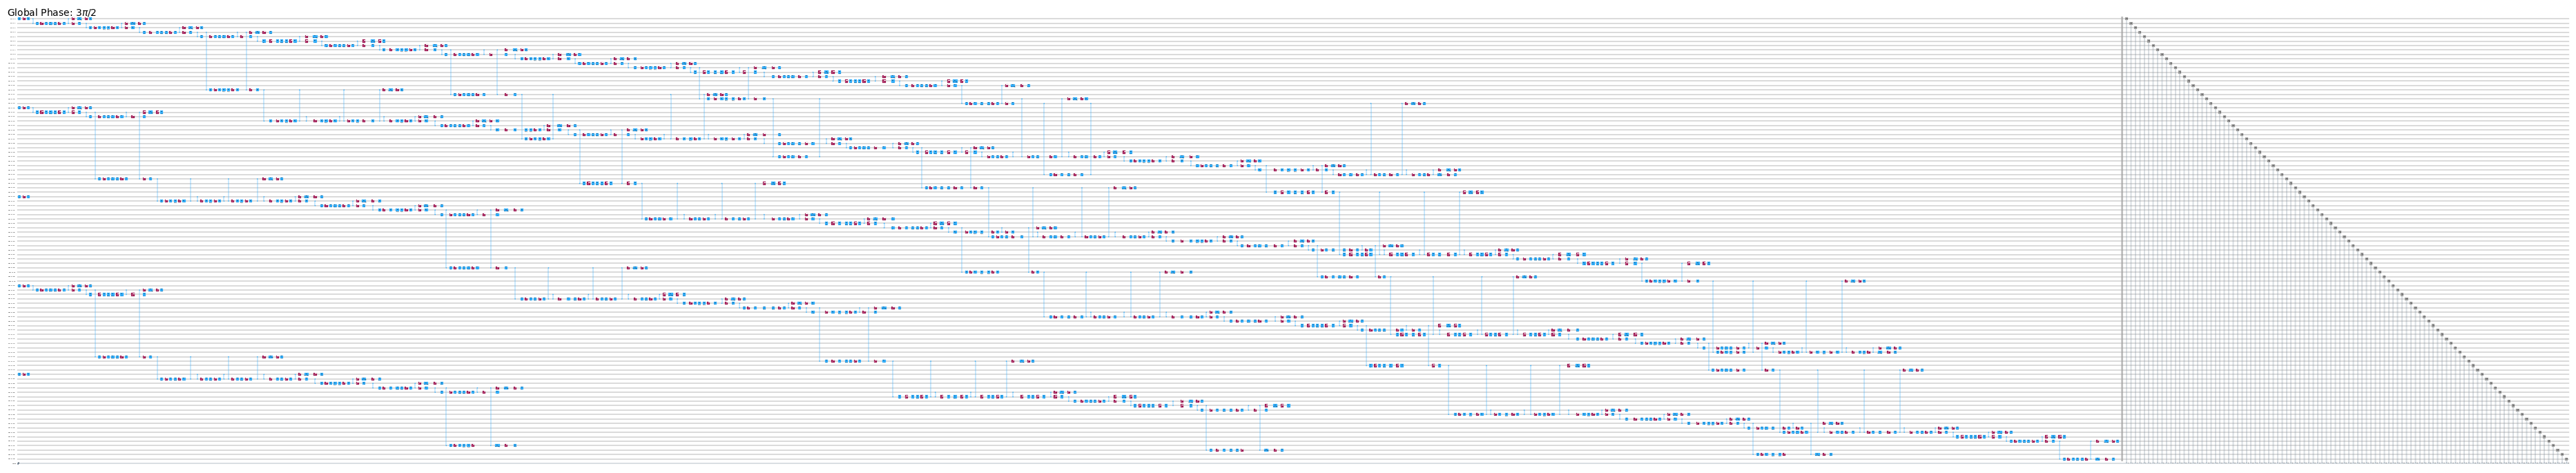

In [22]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=3,
                                    backend=backend)

candidate_circuit_100 = pm.run(circuit_100)
candidate_circuit_100.draw('mpl', fold=False, scale=0.1, idle_wires=False)

### Step 3. Execute using Qiskit primitives

To run QAOA, you must know the optimal parameters $\gamma_k$ and $\beta_k$ to put in the variational circuit. Optimize these parameters by running an optimization loop on the device. The cell submits jobs until the cost function value has converged and the optimal parameters for $\gamma_k$ and $\beta_k$ are determined.


#### Find candidate solution by running the optimization on the device


First, run the optimization loop for the circuit parameters on a device.


In [23]:
initial_gamma = np.pi
initial_beta = np.pi/2
init_params = [initial_gamma, initial_beta]

objective_func_vals = [] # Global variable
with Session(backend=backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)

    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit_100, cost_hamiltonian_100, estimator),
        method="COBYLA",
        options={
            "maxiter": 30,
            "tol": 1e-2,
        },
    )
    print(result)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -2.1412456078556947
       x: [ 3.190e+00  1.583e+00]
    nfev: 17
   maxcv: 0.0


Once the optimal parameters from running QAOA on the device have been found, assign the parameters to the circuit


In [24]:
optimized_circuit_100 = candidate_circuit_100.assign_parameters(result.x)
optimized_circuit_100.draw('mpl', fold=False, idle_wires=False)

Finally, execute the circuit with the optimal parameters to sample from the corresponding distribution.


In [25]:
# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"


pub= (optimized_circuit_100, )
job = sampler.run([pub], shots=int(1e4))

counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_100_int = {key: val/shots for key, val in counts_int.items()}

### Step 4. Post-process, return result in classical format


Check that the cost minimized in the optimization loop has converged to a certain value. The code below uses the parameters corresponding to the minimum value of the cost.


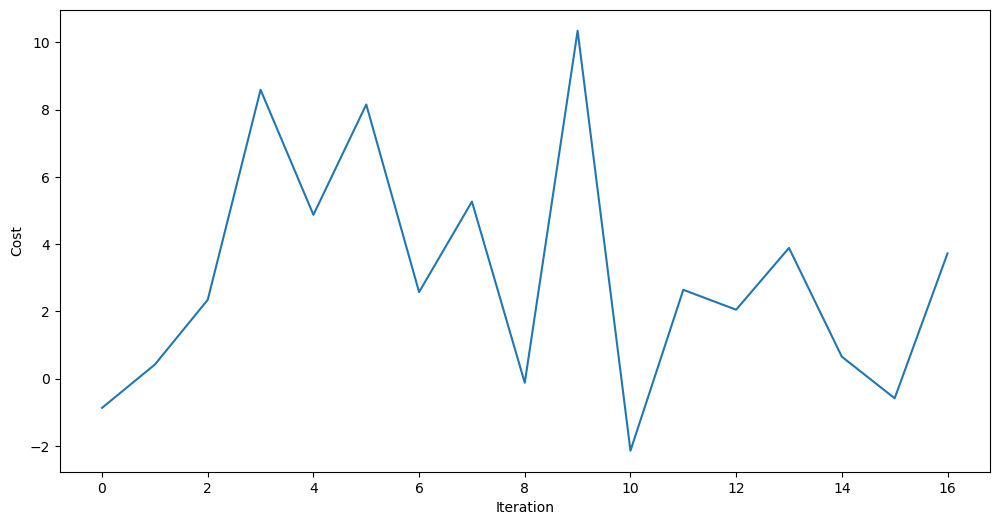

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

We can now calculate the cut with the most likely bitstring, as we did in the small scale example. 

In [43]:
keys_100 = list(final_distribution_100_int.keys())
values_100 = list(final_distribution_100_int.values())
most_likely_100 = keys_100[np.argmax(np.abs(values_100))]
most_likely_bitstring_100 = to_bitstring(most_likely_100, len(graph_100))
most_likely_bitstring_100.reverse()

print("Result bitstring:", most_likely_bitstring_100)

cut_value_100_most_likely = evaluate_sample(most_likely_bitstring_100, graph_100)
print('Looking at the most likely bitstring, the value of the cut is:', cut_value_100_most_likely)

Result bitstring: [0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
Looking at the most likely bitstring, the value of the cut is: 90


However given that the likelihood of each solution is low, since we have a Hilbert space of $2^{100}$, we will extract the solution that corresponds to the lowest cost.

In [27]:
_PARITY = np.array([-1 if bin(i).count("1") % 2 else 1 for i in range(256)], dtype=np.complex128)


def evaluate_sparse_pauli(state: int, observable: SparsePauliOp) -> complex:
    """Utility for the evaluation of the expectation value of a measured state."""
    packed_uint8 = np.packbits(observable.paulis.z, axis=1, bitorder="little")
    state_bytes = np.frombuffer(state.to_bytes(packed_uint8.shape[1], "little"), dtype=np.uint8)
    reduced = np.bitwise_xor.reduce(packed_uint8 & state_bytes, axis=1)
    return np.sum(observable.coeffs * _PARITY[reduced])

def best_solution(samples, hamiltonian):
    """Find solution with lowest cost"""
    min_cost = 1000
    min_sol = None
    for bit_str in samples.keys():
        
        candidate_sol = int(bit_str)
        
        fval = evaluate_sparse_pauli(candidate_sol, hamiltonian).real
        if fval <= min_cost:
            min_cost = fval
            min_sol = candidate_sol

    return min_sol

best_sol_100 = best_solution(final_distribution_100_int, cost_hamiltonian_100)
best_sol_bitstring_100 = to_bitstring(int(best_sol_100), len(graph_100))
best_sol_bitstring_100.reverse()

print("Result bitstring:", best_sol_bitstring_100)

Result bitstring: [0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1]


Next, visualize the cut. Nodes of the same color belong to the same group.


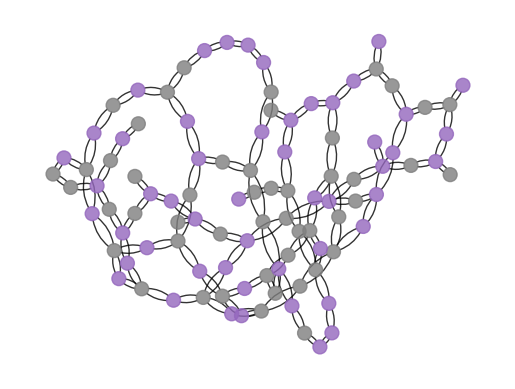

In [28]:
plot_result(graph_100, best_sol_bitstring_100)

And calculate the the value of the cut


In [29]:
cut_value_100 = evaluate_sample(best_sol_bitstring_100, graph_100)
print('The value of the cut is:', cut_value_100)

The value of the cut is: 144


In [42]:
keys_100 = list(final_distribution_100_int.keys())
values_100 = list(final_distribution_100_int.values())
most_likely_100 = keys_100[np.argmax(np.abs(values_100))]
most_likely_bitstring_100 = to_bitstring(most_likely_100, len(graph_100))
most_likely_bitstring_100.reverse()

print("Result bitstring:", most_likely_bitstring_100)

cut_value_100_most_likely = evaluate_sample(most_likely_bitstring_100, graph_100)
print('The value of the cut is:', cut_value_100_most_likely)

Result bitstring: [0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
The value of the cut is: 90


## Conclusion

In this hands-on we have seen how to solve an optimization problem with a quantum computer using the Qiskit patterns framework. The demonstration included a utility-scale example, with circuit sizes that cannot be exactly simulated classically. Currently, quantum computers do not outperform classical computers for combinatorial optimization because of noise. However, the hardware is steadily improving, and new algorithms for quantum computers are continually being developed. Indeed, much of the research working on quantum heuristics for combinatorial optimization is tested with classical simulations that only allow for a small number of qubits, typically around 20 qubits. Now, with larger qubit counts and devices with less noise, researchers will be able to start benchmarking these quantum heuristics at large problem sizes on quantum hardware.


# Bonus: Optimization Mapper Addon

After introducing how to solve a Max-Cut problem with QAOA, we can now take a step further and use the Qiskit Optimization Addon Mapper to make better use of the algorithm. In this section, we consider the same scaled‑up instance consisting of the previous graph with 100 nodes, which corresponds to 100 qubits, and we aim to solve it while improving the solution.

In [ ]:
%pip install 'qiskit-addon-opt-mapper'
%pip install git+https://github.com/qiskit-community/qopt-best-practices.git

In [30]:
from qiskit_addon_opt_mapper.applications import Maxcut
from qiskit_addon_opt_mapper.translators import to_ising
from qopt_best_practices.circuit_library import annotated_qaoa_ansatz
from qopt_best_practices.transpilation import UnrollBoxes

In [31]:
p_layers = layers
maxcut = Maxcut(graph_100)
print("MaxCut instance:", maxcut)

cost_op = to_ising(maxcut.to_optimization_problem())[0].simplify() 

# Note that we created an ansatz circuit where the individual QAOA cost and QAOA mixer layers are annotated for improved transpilation
qc_mapper = annotated_qaoa_ansatz(cost_op, reps=p_layers)
qc_mapper.measure_all(inplace=True)
qc_mapper.draw(fold=-1, idle_wires=False)

MaxCut instance: <qiskit_addon_opt_mapper.applications.max_cut.Maxcut object at 0x3daf1fa10>


┌─────── ┌───┐ ───────┐ ┌───────                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      ───────┐ ┌─────── ┌────────────┐ ───────┐  ░ ┌─┐                                                                                                                                                                                                                                                                                                         
     q_0: ┤        ┤ H ├        ├─┤        ─■──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────        ├─┤        ┤ Rx(2*β[0]) ├        ├──░─┤M├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
          │        ├───┤        │ │         │ZZ(2*γ[0])                                                                                                                                                                                                                                                                                                                                                                                                                                                                                │ │        ├────────────┤        │  ░ └╥┘┌─┐                                                                                                                                                                                                                                                                                                      
     q_1: ┤        ┤ H ├        ├─┤        ─■────────────■─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────        ├─┤        ┤ Rx(2*β[0]) ├        ├──░──╫─┤M├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
          │        ├───┤        │ │                      │ZZ(2*γ[0])                                                                                                                                                                                                                                                                                                                                                                                                                                                                   │ │        ├────────────┤        │  ░  ║ └╥┘┌─┐            

In [32]:
isa_qc_mapper = generate_preset_pass_manager(backend).run(UnrollBoxes()(qc_mapper))

Let's compare the circuit depth, as well as the number of two-qubit and single-qubit gates, between the circuit obtained after transpilation with the optimization mapper (`isa_qc_mapper`) and the previous circuit generated without it (`candidate_circuit_100`).

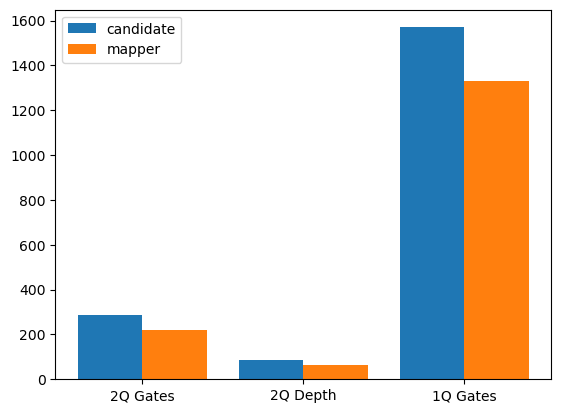

In [44]:
def get_metrics(qc):
    return (
        qc.num_nonlocal_gates(),                         # 2Q gate count
        qc.depth(lambda x: len(x.qubits) == 2),          # 2Q depth
        qc.size() - qc.num_nonlocal_gates()              # 1Q gates (approx)
    )

cand = get_metrics(candidate_circuit_100)
mapper = get_metrics(isa_qc_mapper)

labels = ["2Q Gates", "2Q Depth", "1Q Gates"]
x = range(3)

plt.bar([i-0.2 for i in x], cand, 0.4, label="candidate")
plt.bar([i+0.2 for i in x], mapper, 0.4, label="mapper")
plt.xticks(x, labels)
plt.legend()
plt.show()

Now, we run QAOA:

In [35]:

objective_func_vals = [] # Global variable
with Session(backend=backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)

    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(isa_qc_mapper, cost_op, estimator),
        method="COBYLA",
        options={
            "maxiter": 30,
            "tol": 1e-2,
        },

    )
    print(result)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -35.67747171275906
       x: [ 3.482e+00  2.753e+00]
    nfev: 18
   maxcv: 0.0


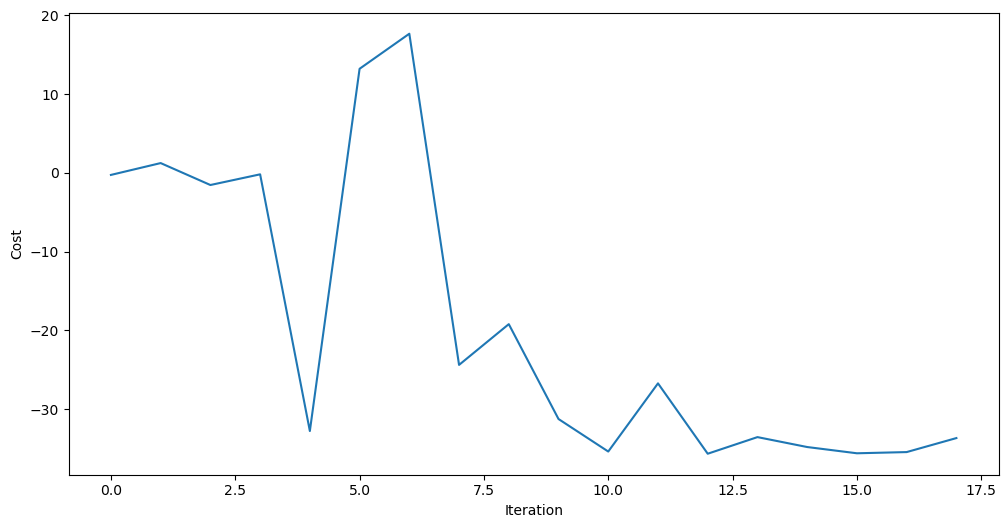

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [37]:
optimized_mapper_100 = isa_qc_mapper.assign_parameters(result.x)

In [38]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"


pub= (optimized_mapper_100, )
job = sampler.run([pub], shots=int(1e4))

counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_100_int_mapper = {key: val/shots for key, val in counts_int.items()}

In [39]:
best_sol_100_mapper = best_solution(final_distribution_100_int_mapper , cost_op)
best_sol_bitstring_100_mapper = to_bitstring(int(best_sol_100_mapper), len(graph_100))
best_sol_bitstring_100_mapper.reverse()

print("Result bitstring:", best_sol_bitstring_100_mapper)

Result bitstring: [0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1]


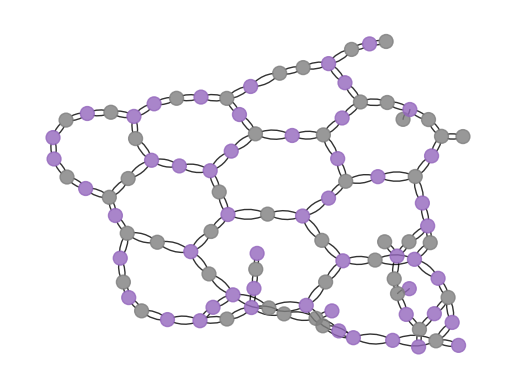

In [40]:
plot_result(graph_100, best_sol_bitstring_100_mapper)

In [41]:
cut_value_100_mapper = evaluate_sample(best_sol_bitstring_100_mapper, graph_100)
print('The value of the cut is:', cut_value_100_mapper)

The value of the cut is: 176


The results show that the cut value increased, indicating a better solution to the Max-Cut problem on the 100 node graph. This improvement highlights how the optimization mapper can significantly enhance the performance of QAOA when tackling large‑scale optimization problems.